<a href="https://colab.research.google.com/github/banotahira0915-bano/Colab--amlcodes/blob/main/Exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:33:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== ACCURACY SCORES =====
Bagging Accuracy : 0.956140350877193
AdaBoost Accuracy: 0.9649122807017544
XGBoost Accuracy : 0.956140350877193

===== CLASSIFICATION REPORT (XGBoost) =====
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


===== MODEL COMPARISON =====
      Model  Accuracy
0   Bagging  0.956140
1  AdaBoost  0.964912
2   XGBoost  0.956140


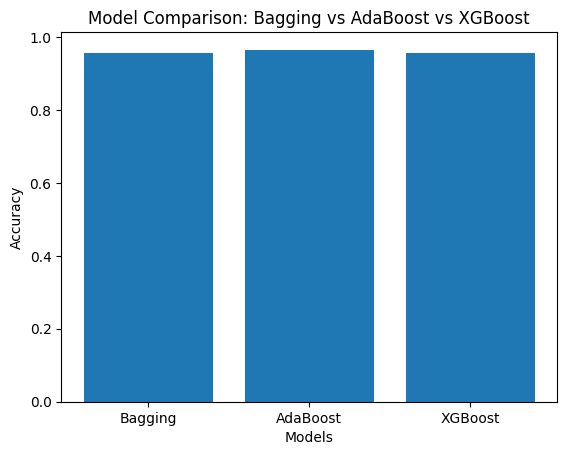

In [ ]:
# ================================
# 1. Install XGBoost (if not installed)
# ================================
!pip install xgboost

# ================================
# 2. Import Libraries
# ================================
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

# ================================
# 3. Load Dataset
# ================================
data = load_breast_cancer()
X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 4. Train Bagging Classifier
# ================================
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

# ================================
# 5. Train AdaBoost
# ================================
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1,
    random_state=42
)

adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)

# ================================
# 6. Train XGBoost
# ================================
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ================================
# 7. Evaluation
# ================================
print("===== ACCURACY SCORES =====")
print("Bagging Accuracy :", accuracy_score(y_test, y_pred_bag))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("XGBoost Accuracy :", accuracy_score(y_test, y_pred_xgb))

print("\n===== CLASSIFICATION REPORT (XGBoost) =====")
print(classification_report(y_test, y_pred_xgb))

# ================================
# 8. Comparison Table
# ================================
results = pd.DataFrame({
    'Model': ['Bagging', 'AdaBoost', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print("\n===== MODEL COMPARISON =====")
print(results)

# ================================
# 9. Plot Comparison
# ================================
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results['Model'], results['Accuracy'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison: Bagging vs AdaBoost vs XGBoost")
plt.show()